# 이탈 예측 모델 검증 — 베이스라인 대비 · 사전 기준 판정

**작성** 2026-09-06 · **원천** BigQuery (`calm_forest_raw.game_logs` × `analytics_547127440`)
· **표본 정의** [`ml/sql/churn_trigger_sample.sql`](../sql/churn_trigger_sample.sql)
· **학습 코드** [`ml/train_churn.py`](../train_churn.py)

이 노트북은 모델을 **만드는** 자리가 아니라, 이미 돌아가는 파이프라인이 낸 숫자를
**사전에 정해둔 기준에 대보는** 자리다. 기준은 착수 전에 고정했고 사후에 바꾸지 않는다.

> **사전 기준** (`docs/CHURN_ANALYSIS_PLAN.md` §5 · 설계서 §12)
> AUC 95% 신뢰구간의 **하한** 이 0.60 을 넘으면 신호 있음 · 0.50~0.60 이면 보류 · 0.50 이하면 기각.
> 검증은 `GroupKFold(client_id)` 5겹 + 부트스트랩 1,000회. 베이스라인 둘을 반드시 같이 낸다.

**용어 하나만 먼저** — **AUC** 는 "이탈한 사람과 안 한 사람을 하나씩 뽑았을 때,
모델이 이탈한 쪽에 더 높은 점수를 줄 확률"이다. 0.5 는 동전 던지기, 1.0 은 완벽.
`0.77` 은 "열 쌍 중 일곱 쌍 반은 순서를 맞힌다"는 뜻이다.

## 한 줄 답

**사전 기준은 통과했다 — 그런데 통과분의 대부분은 "어떤 트리거였나" 하나에서 나온다.**

전체 표본(n=724)에서 AUC 0.768, 95% CI [0.728, 0.804] 로 **하한이 0.60 을 넘어 "신호 있음"** 이다.
그런데 트리거 종류(15초냐 퀘스트냐)만 아는 모델도 혼자 AUC 0.684 를 낸다.
**같은 트리거 안에서만 비교하면 AUC 는 0.60~0.64 로 내려앉고 신뢰구간은 0.60 을 물고 있다.**

즉 모델은 "지금 15초 트리거구나 → 위험하다"를 잘 배웠고,
"같은 15초 트리거 중에 누가 더 위험한가"는 겨우 배웠다.
**파이프라인은 유지하고 계수는 갈아끼운다**(설계서 §12) — 다만 개입 효과를 볼 때
모델 점수를 트리거 안에서 쓰고 있다는 사실을 잊으면 안 된다.

아래 숫자는 전부 이 노트북이 그 자리에서 다시 계산한 값이다. 붙여넣은 값이 아니다.

In [1]:
import warnings
# ① BigQuery Storage 가속 모듈 없음 — 결과가 수백 행이라 REST 로 충분하다.
# ② sklearn 1.8 의 penalty= 폐기 예고 — train_churn.py 가 쓰는 인자라 여기서 고칠 수 없다.
warnings.filterwarnings("ignore", message=".*BigQuery Storage.*")
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.*")

import sys
from pathlib import Path

# 노트북은 ml/notebooks/ 에서 돈다. train_churn.py 는 ml/ 에 있고 패키지가 아니라
# 스크립트라 sys.path 를 직접 넣는다(계산을 여기 다시 구현하지 않기 위해서다).
ML = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ML))

import numpy as np
import pandas as pd

from calm_ml import bq, report as R
# 서빙에 실제로 쓰이는 학습 코드를 그대로 import 한다. 노트북에 다시 구현하면
# "노트북에서는 되는데 서빙은 다른 숫자" 가 생긴다. 밑줄로 시작하는 이름(_prepare 등)은
# 비공개지만, 같은 저장소 안의 검증 노트북이라 그대로 쓴다.
from train_churn import (FEATURE_ORDER, SQL, _bootstrap_ci, _cv_oof, _prepare,
                         _thresholds, fit_and_export)

R.setup()
pd.set_option("display.max_rows", 40)
np.set_printoptions(suppress=True)

CAP = 20          # 클라이언트당 세션 상한 — 설계서 §5 확정값
SEED = 0          # 부트스트랩 시드. train_churn._bootstrap_ci 기본값과 같다
print("피처 8개:", FEATURE_ORDER)

피처 8개: ['path_len', 'net_disp', 'wander_ratio', 'yaw_total', 'mouse_travel', 'idle_ratio', 'is_first_session', 'trigger_kind']


## 1. 표본이 얼마나 되고, 무엇으로 이루어져 있나

모델 이야기를 하기 전에 **몇 건으로 재는지**부터 본다. 표본이 작으면 어떤 숫자든
다음 주에 뒤집힌다.

표본 한 행 = **트리거 한 번**이다. 세션 하나가 여러 행을 낼 수 있다 —
15초 트리거는 세션당 1건이지만 퀘스트 트리거는 퀘스트를 만질 때마다 1건이다.
라벨 `y=1` 은 **그 트리거 시점부터 60초 안에 세션이 끝났다**는 뜻이다.

In [2]:
# 표본 정의는 SQL 파일 하나뿐이다. 노트북에 쿼리를 복사하지 않는다 —
# 두 곳에 두면 반드시 갈라진다.
df = bq.read_sql_file(str(SQL), cap=CAP)

by = (df.groupby("trigger_kind")
        .agg(건수=("y", "size"), 이탈률=("y", "mean"),
             세션=("session_id", "nunique"), 클라이언트=("client_id", "nunique")))
print(f"표본 {len(df):,}건 · 세션 {df.session_id.nunique():,}개 · 클라이언트 {df.client_id.nunique():,}개")
print(f"전체 이탈률 {df.y.mean():.1%}\n")
print(by.to_string(formatters={"이탈률": "{:.1%}".format}))

표본 724건 · 세션 293개 · 클라이언트 156개
전체 이탈률 30.1%

               건수    이탈률   세션  클라이언트
trigger_kind                        
quest         440  13.9%   62     46
time15        284  55.3%  284    149


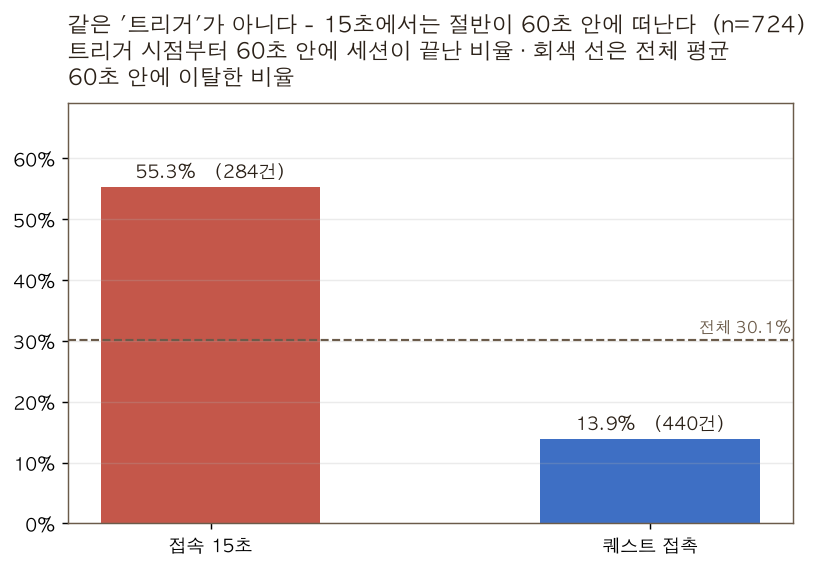

In [3]:
n = len(df)
order = ["time15", "quest"]
KO_TRIG = {"time15": "접속 15초", "quest": "퀘스트 접촉"}
rate = [by.loc[k, "이탈률"] for k in order]
cnt = [int(by.loc[k, "건수"]) for k in order]

fig, ax = R.new("같은 '트리거'가 아니다 - 15초에서는 절반이 60초 안에 떠난다", n=n,
                sub="트리거 시점부터 60초 안에 세션이 끝난 비율 · 회색 선은 전체 평균",
                ylab="60초 안에 이탈한 비율", figsize=(7.2, 4.2))
ax.bar([KO_TRIG[k] for k in order], rate, color=[R.PALETTE[0], R.PALETTE[1]], width=0.5)
ax.axhline(df.y.mean(), color=R.MUTED, lw=1.2, ls="--")
ax.annotate(f"전체 {df.y.mean():.1%}", (1.32, df.y.mean()), xytext=(0, 4),
            textcoords="offset points", fontsize=9, color=R.MUTED, ha="right")
for i, (r_, c_) in enumerate(zip(rate, cnt)):
    ax.text(i, r_ + 0.015, f"{r_:.1%}   ({c_:,}건)", ha="center", fontsize=10, color=R.INK)
ax.set_ylim(0, max(rate) * 1.25)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="x", visible=False)
R.show(R.save(fig, ax, "g_ch_sample"))

### 읽은 것

**두 트리거는 위험도가 근본적으로 다른 순간이다.** 접속 15초 시점에서는 **55.3%** 가
1분 안에 떠나고, 퀘스트를 만진 직후에는 **13.9%** 만 떠난다. 4배 차이다.

이래서 임계값을 하나로 둘 수 없다(설계서 §4). 0.5 하나를 쓰면 15초 트리거에서는
거의 항상 배너가 뜨고 퀘스트에서는 거의 안 뜬다. **임계값 = 그 트리거의 기저율** 로 둔 이유다.

그리고 이 차이가 뒤에서 문제가 된다 — 모델이 트리거 종류만 봐도 점수를 꽤 잘 매기기 때문이다.

### 상한(cap)을 걸기 전과 후

한 사람이 표본을 독차지하면 그 사람의 습관을 "이탈 신호" 로 배운다.
그래서 클라이언트당 세션 수에 상한을 둔다. 얼마나 깎이는지 본다.

In [4]:
# 상한을 사실상 없앤 판. 같은 SQL, @cap 만 크게 준다.
df_nocap = bq.read_sql_file(str(SQL), cap=1_000_000)

def top3_share(d):
    # 상위 3개 클라이언트가 표본의 몇 %를 차지하는가 — 편중 지표
    return d.client_id.value_counts().head(3).sum() / len(d)

cap_tbl = pd.DataFrame({
    "표본(건)": [len(df_nocap), len(df)],
    "클라이언트": [df_nocap.client_id.nunique(), df.client_id.nunique()],
    "상위3 기기 점유": [top3_share(df_nocap), top3_share(df)],
    "이탈률": [df_nocap.y.mean(), df.y.mean()],
}, index=["상한 없음", f"상한 {CAP}세션"])
print(cap_tbl.to_string(formatters={"상위3 기기 점유": "{:.1%}".format, "이탈률": "{:.1%}".format}))

         표본(건)  클라이언트 상위3 기기 점유   이탈률
상한 없음      851    156     24.8% 31.3%
상한 20세션    724    156     21.7% 30.1%


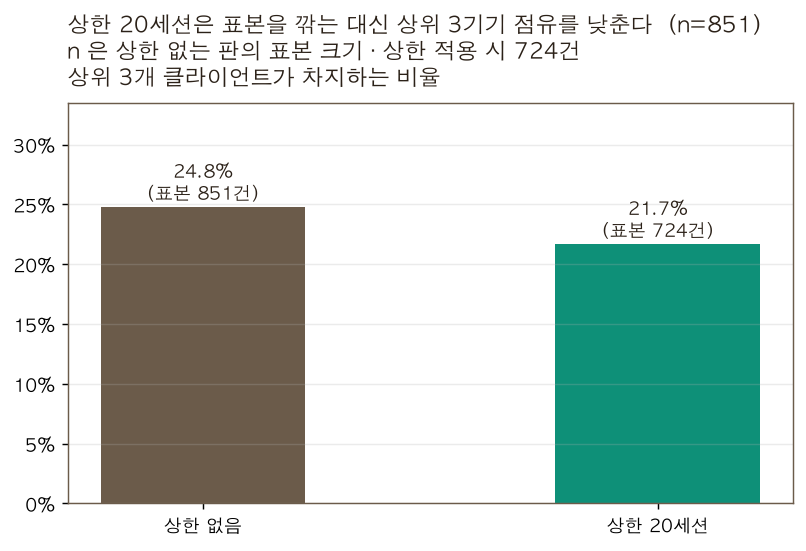

In [5]:
fig, ax = R.new("상한 20세션은 표본을 깎는 대신 상위 3기기 점유를 낮춘다", n=len(df_nocap),
                sub=f"n 은 상한 없는 판의 표본 크기 · 상한 적용 시 {len(df):,}건",
                ylab="상위 3개 클라이언트가 차지하는 비율", figsize=(7.2, 4.0))
sh = cap_tbl["상위3 기기 점유"].to_list()
ax.bar(cap_tbl.index, sh, color=[R.MUTED, R.PALETTE[2]], width=0.45)
for i, (v, nn) in enumerate(zip(sh, cap_tbl["표본(건)"])):
    ax.text(i, v + 0.006, f"{v:.1%}\n(표본 {nn:,}건)", ha="center", fontsize=10, color=R.INK)
ax.set_ylim(0, max(sh) * 1.35)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="x", visible=False)
R.show(R.save(fig, ax, "g_ch_cap"))

### 읽은 것

상한을 걸면 표본이 **851 → 724건**(-15%) 으로 줄고, 상위 3개 기기의 점유가
**24.8% → 21.7%** 로 내려간다. 클라이언트 수는 156명으로 같다 — 상한은 사람을 빼는 게 아니라
많이 낸 사람의 세션만 자른다.

**이 편중은 없어지지 않았다.** 156명 중 3명이 여전히 표본의 5분의 1이다.
아래 모든 숫자는 그 사실 위에 얹혀 있다. `GroupKFold(client_id)` 로
같은 사람이 학습·검증에 동시에 들어가는 것만 막았을 뿐이다.

> **참고** — 표본은 이틀 만에 507건(2026-09-04) → 724건(2026-09-06)으로 늘었다.
> 베타 세션이 쌓이고 있다는 뜻이고, 아래 판정은 **오늘 표본 기준**이다.

## 2. 피처 8개는 각각 이탈을 얼마나 가리나

모델에 넣기 전에, **피처 하나만으로도 이탈과 잔존이 갈리는지** 본다.
하나도 안 갈리는데 여덟을 합쳐서 갈린다면 그건 대개 우연이다.

먼저 8개를 한눈에 — 각 피처 **하나만** 넣은 로지스틱 회귀의 AUC 다.
**회귀가 방향(부호)까지 스스로 학습한다**는 점이 중요하다. 그래서 0.5 아래로 내려간 값은
"정보가 반대" 라는 뜻이 아니라, **학습 폴드에서 잡은 방향이 처음 보는 사람에게서 뒤집혔다**
= 그 피처가 사람마다 방향이 달라 못 믿는다는 뜻이다.

비교를 위해 **전체를 한 판으로 그냥 잰 AUC**(사람을 나누지 않고 값 자체로 순위를 매긴 것)도
같이 찍는다. 둘이 크게 다르면 그 피처는 사람 사이(between)와 사람 안(within)에서
다르게 움직이는 것이다.

In [6]:
X, y, groups, impute = _prepare(df)      # 학습 코드와 완전히 같은 전처리·대치
print(f"X {X.shape} · 이탈 {y.sum():,}건 / 잔존 {(1 - y).sum():,}건 · 그룹(클라이언트) {len(set(groups)):,}개")
print("대치값(서빙에서 결측일 때 API 가 쓰는 값):")
print({k: round(v, 3) for k, v in impute.items()})

# 피처 하나짜리 모델의 GroupKFold AUC. 전체 모델과 똑같은 절차라 바로 비교된다.
# 옆에 '그냥 전체로' 잰 AUC 를 같이 둔다 — 부호 학습 없이 값 자체로 순위를 매긴 것.
from sklearn.metrics import roc_auc_score

uni = pd.DataFrame({
    "GroupKFold AUC": {f: _cv_oof(X[:, [FEATURE_ORDER.index(f)]], y, groups)[0] for f in FEATURE_ORDER},
    "그냥 전체로": {f: roc_auc_score(y, X[:, FEATURE_ORDER.index(f)]) for f in FEATURE_ORDER},
}).sort_values("GroupKFold AUC", ascending=False)
single = uni["GroupKFold AUC"]          # 아래 차트·캡션이 쓰는 값
print()
print(uni.round(4).to_string())

X (724, 8) · 이탈 218건 / 잔존 506건 · 그룹(클라이언트) 156개
대치값(서빙에서 결측일 때 API 가 쓰는 값):
{'path_len': 8.01, 'net_disp': 5.643, 'wander_ratio': 1.182, 'yaw_total': 0.0, 'mouse_travel': 367.643, 'idle_ratio': 0.111, 'is_first_session': 1.0, 'trigger_kind': 1.0}

                  GroupKFold AUC  그냥 전체로
mouse_travel              0.6841  0.2953
trigger_kind              0.6841  0.2654
path_len                  0.5594  0.6671
net_disp                  0.5358  0.6247
idle_ratio                0.5102  0.4219
yaw_total                 0.5043  0.5580
wander_ratio              0.4342  0.4469
is_first_session          0.3834  0.5297


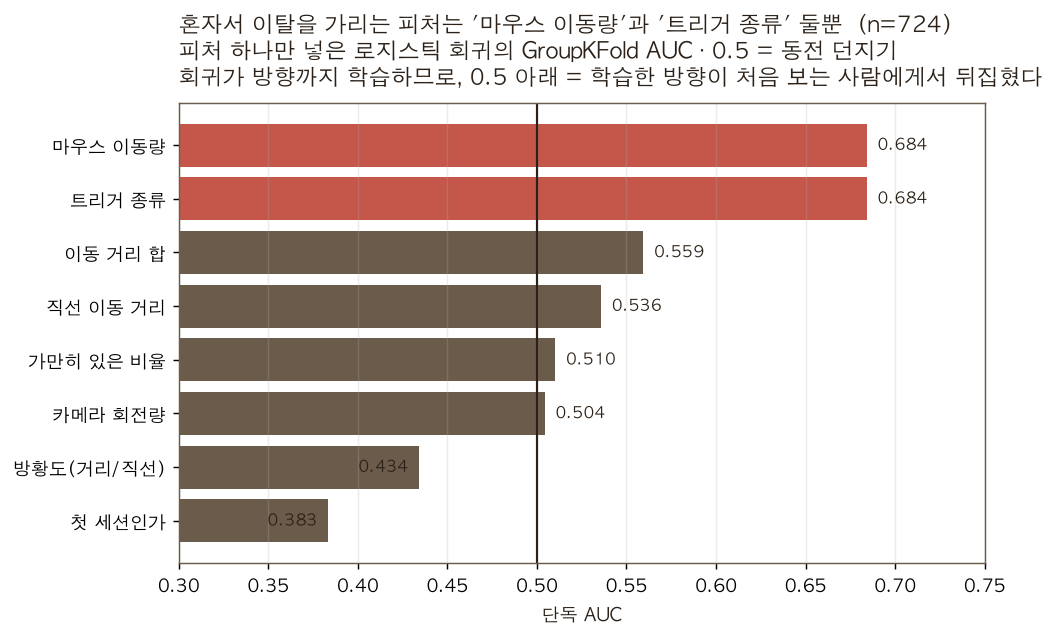

In [7]:
KO_FEAT = {
    "path_len": "이동 거리 합", "net_disp": "직선 이동 거리", "wander_ratio": "방황도(거리/직선)",
    "yaw_total": "카메라 회전량", "mouse_travel": "마우스 이동량", "idle_ratio": "가만히 있은 비율",
    "is_first_session": "첫 세션인가", "trigger_kind": "트리거 종류",
}
s = single.sort_values()
# ⚠️ |AUC-0.5| 로 칠하면 안 된다 — 회귀가 부호를 이미 학습하므로 0.5 아래는
#    "반대 방향 정보" 가 아니라 "방향이 안 잡힌다" 는 뜻이다. 0.58 위만 강조한다.
colors = [R.PALETTE[0] if v >= 0.58 else R.MUTED for v in s]

fig, ax = R.new("혼자서 이탈을 가리는 피처는 '마우스 이동량'과 '트리거 종류' 둘뿐", n=len(y),
                sub="피처 하나만 넣은 로지스틱 회귀의 GroupKFold AUC · 0.5 = 동전 던지기\n"
                    "회귀가 방향까지 학습하므로, 0.5 아래 = 학습한 방향이 처음 보는 사람에게서 뒤집혔다",
                figsize=(8, 4.6))
ax.barh([KO_FEAT[k] for k in s.index], s.to_numpy(), color=colors)
ax.axvline(0.5, color=R.INK, lw=1.2)
ax.set_xlim(0.3, 0.75)
ax.set_xlabel("단독 AUC")
ax.grid(axis="y", visible=False)
for i, v in enumerate(s):
    ax.text(v + 0.006 if v > 0.5 else v - 0.006, i, f"{v:.3f}",
            va="center", ha="left" if v > 0.5 else "right", fontsize=9, color=R.INK)
R.show(R.save(fig, ax, "g_ch_feat_auc", zero_base=False))

### 읽은 것

**0.58 을 확실히 넘는 건 둘뿐이다** — **마우스 이동량 0.684** 와 **트리거 종류 0.684**.
`path_len` 0.559 · `net_disp` 0.536 은 겨우 0.5 위이고, 나머지 넷은 사실상 정보가 없다.

- **마우스 이동량**이 제일 세다. 방향은 **적게 움직일수록 이탈** 이다(그냥 전체로 재면 0.295 —
  값이 작은 쪽에 이탈이 몰려 있다는 뜻). 그럴듯하지만 이건 "이미 손을 뗐다" 를 재는 것에 가깝지
  이탈을 **예고** 하는 게 아닐 수 있다.
- **트리거 종류**는 1절에서 본 기저율 차이(55.3% vs 13.9%)를 그대로 다시 말하는 값이다.
  피처라기보다 **표본이 두 덩어리라는 사실** 이다.
- **첫 세션인가 0.383 · 방황도 0.434 는 0.5 아래로 내려갔다.** 회귀가 부호를 이미 고르는데도
  아래로 갔다는 건 **학습 폴드에서 잡은 방향이 처음 보는 사람에게서 뒤집혔다** 는 뜻이다.
  실제로 첫 세션은 '그냥 전체로' 재면 0.530 으로 0.5 코앞이다 — 사람 사이에서는 거의 차이가 없는데
  사람 안에서 방향이 제각각이다. **반대 정보가 아니라 잡음** 으로 읽어야 한다.
- **`path_len` 은 사람을 나누느냐에 따라 0.667 → 0.559 로 떨어진다.** "많이 움직이는 사람"과
  "많이 움직인 순간" 이 섞여 있었다는 뜻이다. `GroupKFold` 를 쓴 이유가 이거다.

아래에서 8개 분포를 하나씩 본다.

### 피처별 분포 — 이탈한 트리거 vs 남은 트리거

값의 단위가 피처마다 통째로 달라서(거리 수천 vs 비율 0~1) 한 장에 겹치지 않고
**한 피처에 한 장씩** 그린다. 꼬리가 길어 상위 1% 는 잘라 보여준다(잘린 건수는 부제에 적었다).

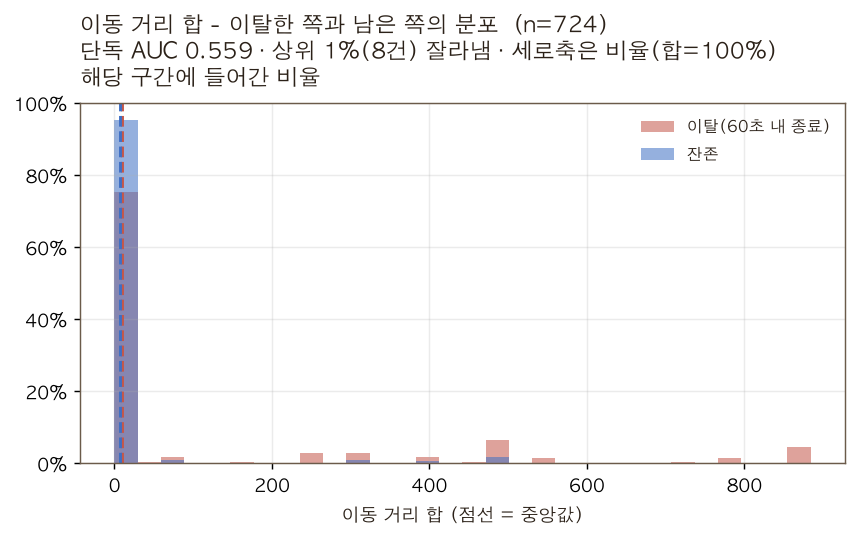

**이동 거리 합** — 중앙값 이탈 `9.43` vs 잔존 `7.4` (이탈 쪽이 높다). GroupKFold 단독 AUC `0.559` → 0.5 에 가까워 **혼자서는 거의 못 가린다**.

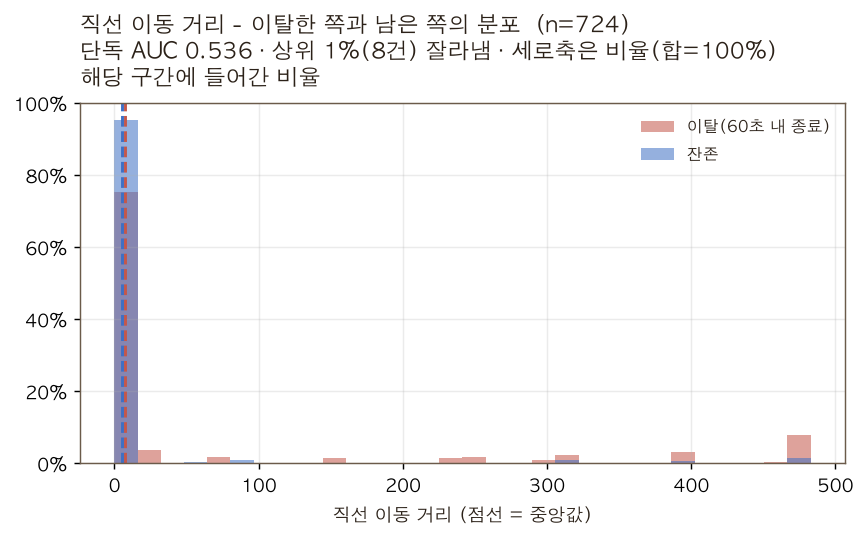

**직선 이동 거리** — 중앙값 이탈 `7.59` vs 잔존 `5.15` (이탈 쪽이 높다). GroupKFold 단독 AUC `0.536` → 0.5 에 가까워 **혼자서는 거의 못 가린다**.

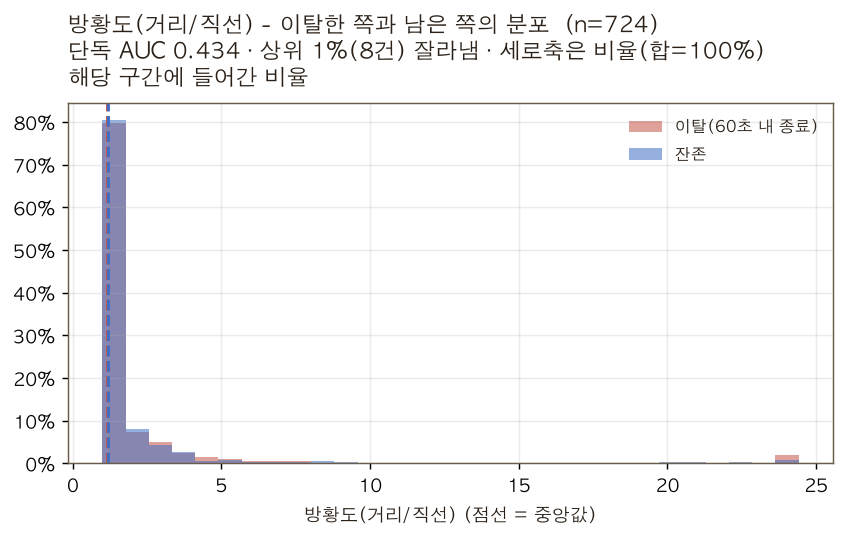

**방황도(거리/직선)** — 중앙값 이탈 `1.16` vs 잔존 `1.18` (이탈 쪽이 낮다). GroupKFold 단독 AUC `0.434` → 학습한 방향이 처음 보는 사람에게서 뒤집힌다. **못 믿는 피처다**.

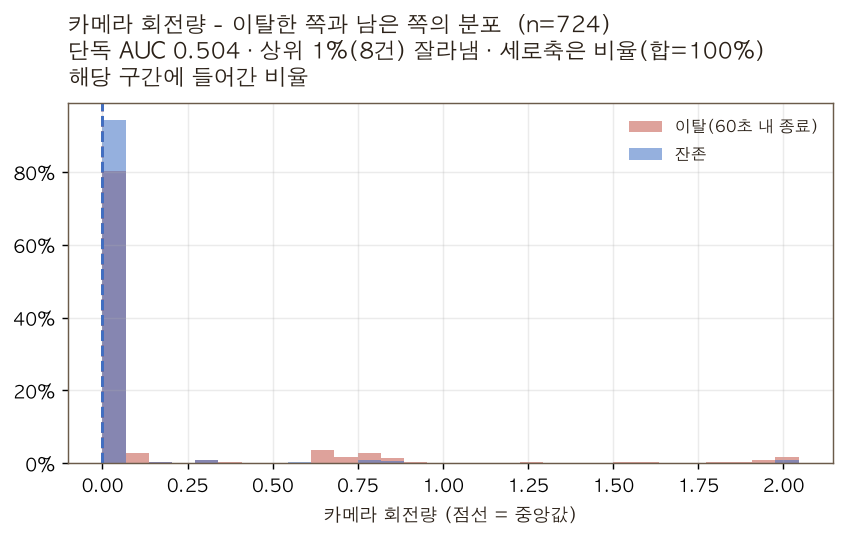

**카메라 회전량** — 중앙값 이탈 `0` vs 잔존 `0` (두 쪽이 같다). GroupKFold 단독 AUC `0.504` → 0.5 에 가까워 **혼자서는 거의 못 가린다**.

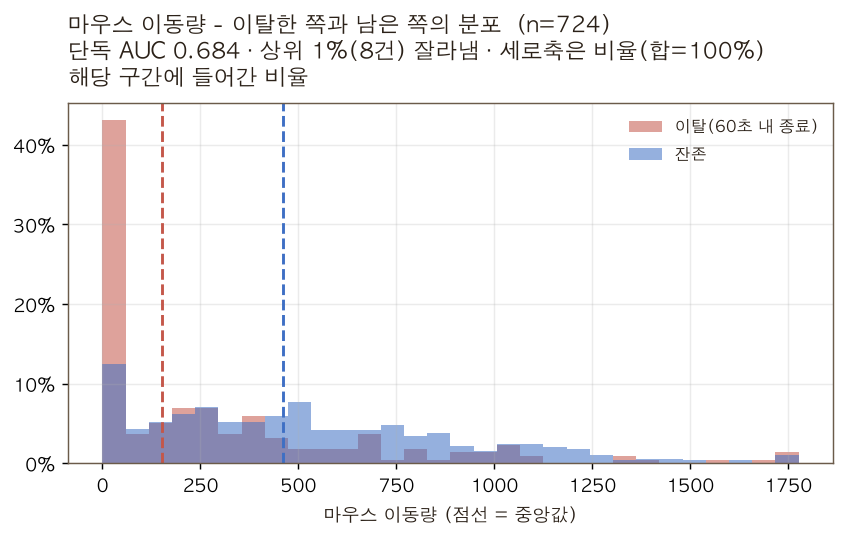

**마우스 이동량** — 중앙값 이탈 `153` vs 잔존 `461` (이탈 쪽이 낮다). GroupKFold 단독 AUC `0.684` → 이 피처 하나로도 어느 정도 갈린다.

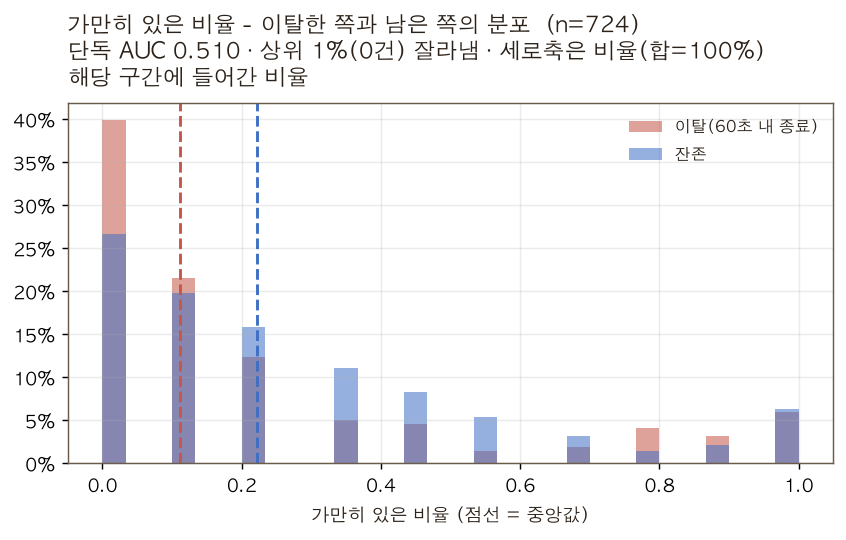

**가만히 있은 비율** — 중앙값 이탈 `0.111` vs 잔존 `0.222` (이탈 쪽이 낮다). GroupKFold 단독 AUC `0.510` → 0.5 에 가까워 **혼자서는 거의 못 가린다**.

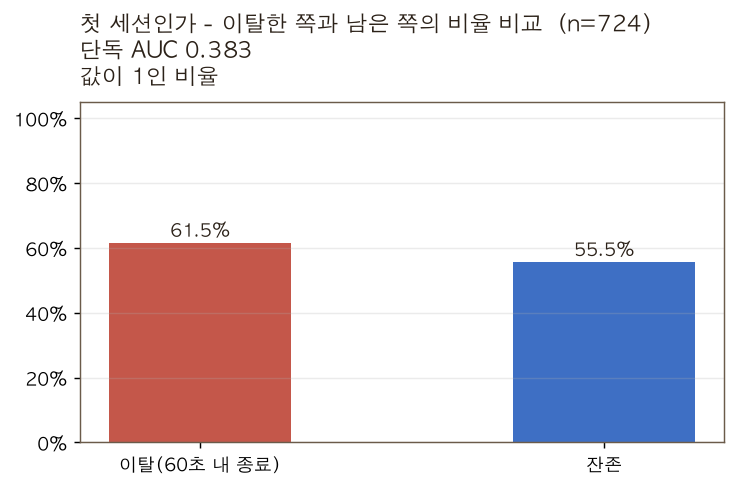

**첫 세션인가** — 1인 비율 이탈 `0.615` vs 잔존 `0.555` (이탈 쪽이 높다). GroupKFold 단독 AUC `0.383` → 학습한 방향이 처음 보는 사람에게서 뒤집힌다. **못 믿는 피처다**.

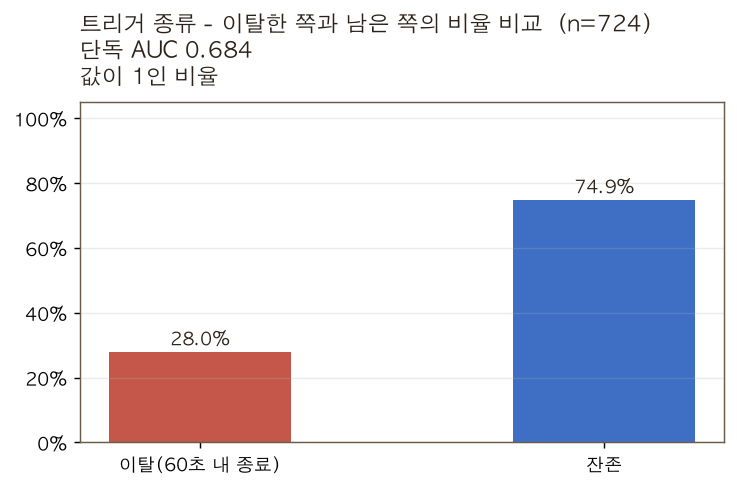

**트리거 종류** — 1인 비율 이탈 `0.28` vs 잔존 `0.749` (이탈 쪽이 낮다). GroupKFold 단독 AUC `0.684` → 이 피처 하나로도 어느 정도 갈린다.

In [8]:
from IPython.display import display, Markdown

BIN = {"is_first_session", "trigger_kind"}   # 0/1 짜리는 히스토그램 대신 비율 막대

def uni_chart(feat: str):
    # 피처 하나의 이탈/잔존 분포를 한 장으로 그리고, 그 아래 설명을 자동으로 붙인다.
    # 설명 문구의 숫자는 전부 여기서 계산한 값이다 — 사람이 기억으로 적으면 본문과 차트가 갈린다.
    v = X[:, FEATURE_ORDER.index(feat)]
    a, b = v[y == 1], v[y == 0]                      # a=이탈, b=잔존
    auc = single[feat]
    ko = KO_FEAT[feat]

    if feat in BIN:
        # 0/1 피처: "값이 1인 비율" 을 두 집단에서 비교한다
        fig, ax = R.new(f"{ko} - 이탈한 쪽과 남은 쪽의 비율 비교", n=len(v),
                        sub=f"단독 AUC {auc:.3f}", ylab="값이 1인 비율", figsize=(6.4, 3.4))
        ax.bar(["이탈(60초 내 종료)", "잔존"], [a.mean(), b.mean()],
               color=[R.PALETTE[0], R.PALETTE[1]], width=0.45)
        for i, val in enumerate([a.mean(), b.mean()]):
            ax.text(i, val + 0.02, f"{val:.1%}", ha="center", fontsize=10, color=R.INK)
        ax.set_ylim(0, 1.05)
        ax.yaxis.set_major_formatter(lambda t, _: f"{t:.0%}")
        ax.grid(axis="x", visible=False)
    else:
        hi = np.percentile(v, 99)                    # 꼬리가 길어 상위 1% 를 자른다
        cut = int((v > hi).sum())
        bins = np.linspace(v.min(), hi, 31)
        fig, ax = R.new(f"{ko} - 이탈한 쪽과 남은 쪽의 분포", n=len(v),
                        sub=f"단독 AUC {auc:.3f} · 상위 1%({cut}건) 잘라냄 · 세로축은 비율(합=100%)",
                        ylab="해당 구간에 들어간 비율", figsize=(7.6, 3.6))
        for arr, lab, c in [(a, "이탈(60초 내 종료)", R.PALETTE[0]), (b, "잔존", R.PALETTE[1])]:
            ax.hist(np.clip(arr, None, hi), bins=bins, weights=np.full(len(arr), 1 / len(arr)),
                    color=c, alpha=0.55, label=lab)
        for arr, c in [(a, R.PALETTE[0]), (b, R.PALETTE[1])]:
            ax.axvline(np.median(arr), color=c, lw=1.6, ls="--")
        ax.legend(frameon=False, fontsize=9)
        ax.set_xlabel(f"{ko} (점선 = 중앙값)")
        ax.yaxis.set_major_formatter(lambda t, _: f"{t:.0%}")

    display(R.show(R.save(fig, ax, f"g_ch_uni_{feat}", zero_base=False)))
    # 0/1 피처는 중앙값이 둘 다 1 로 나와 비교가 안 된다 — 비율(평균)로 말한다
    stat = "1인 비율" if feat in BIN else "중앙값"
    va, vb = (a.mean(), b.mean()) if feat in BIN else (np.median(a), np.median(b))
    direction = ("이탈 쪽이 높다" if va > vb else
                 "이탈 쪽이 낮다" if va < vb else "두 쪽이 같다")
    verdict_txt = ("→ 이 피처 하나로도 어느 정도 갈린다." if auc >= 0.58 else
                   "→ 학습한 방향이 처음 보는 사람에게서 뒤집힌다. **못 믿는 피처다**."
                   if auc < 0.5 else "→ 0.5 에 가까워 **혼자서는 거의 못 가린다**.")
    display(Markdown(
        f"**{ko}** — {stat} 이탈 `{va:,.3g}` vs 잔존 `{vb:,.3g}` ({direction}). "
        f"GroupKFold 단독 AUC `{auc:.3f}` " + verdict_txt))

for f in FEATURE_ORDER:
    uni_chart(f)

### 8장을 한꺼번에 읽으면

분포가 눈에 띄게 갈리는 건 **마우스 이동량** 하나다 — 이탈한 트리거의 43% 가
마우스를 거의 안 움직인 최하위 구간에 몰려 있다. **트리거 종류** 는 갈리긴 하지만
"두 덩어리 표본" 이라는 사실을 다시 말하는 것에 가깝다.

나머지 여섯은 두 분포가 거의 포개진다. **`is_first_session` 은 비율만 보면
이탈 61.5% vs 잔존 55.5% 로 이탈 쪽이 조금 높은데도 GroupKFold AUC 는 0.383 이다** —
그 6%p 차이가 사람을 갈라놓으면 남지 않는다는 뜻이고, 앞 절에서 말한 "방향이 안 잡힌다" 가
그림으로는 이렇게 보인다.

**좌표에서 직접 뽑은 다섯(이동 거리·직선거리·방황도·회전량·유휴 비율)이 다 같이 약한 게
이 표본의 실제 모습이다.** 이걸 알고 아래 모델 숫자를 봐야 한다.

## 3. 베이스라인 둘 — 그냥 찍는 것보다 나은가

사전등록 §5 가 요구한 베이스라인 둘을 먼저 세운다.

1. **다수 클래스** — 무조건 "안 떠난다" 고 답하는 모델. 정확도로만 말할 수 있다
   (순위를 매기지 않으므로 AUC 는 정의상 0.5).
2. **`path_len` 단독** — 이동 거리 하나만 쓰는 로지스틱 회귀.
   **8피처 모델이 이걸 못 이기면 기각하고 단일 피처를 결과로 보고한다**(사전등록 §5).

여기에 하나 더 얹는다 — **`trigger_kind` 단독**. 설계서가 요구한 건 아니지만,
2절에서 이게 혼자 0.684 를 낸 걸 봤기 때문에 **8피처 모델이 이걸 이기는지**가
이 노트북의 진짜 질문이 된다.

In [9]:
# ① 다수 클래스 — 정확도만. AUC 는 순위를 안 매기므로 0.5 로 고정이다.
base_majority = float(max(y.mean(), 1 - y.mean()))

# ② path_len 단독 · ③ trigger_kind 단독 — 전체 모델과 똑같은 GroupKFold 절차
auc_pathlen,  oof_pathlen  = _cv_oof(X[:, [FEATURE_ORDER.index("path_len")]],     y, groups)
auc_trigkind, oof_trigkind = _cv_oof(X[:, [FEATURE_ORDER.index("trigger_kind")]], y, groups)

# ④ 8피처 모델
auc_full, oof_full = _cv_oof(X, y, groups)

print(f"① 다수 클래스 정확도      {base_majority:.4f}  (전부 '잔존' 이라 답할 때)")
print(f"② path_len 단독 AUC       {auc_pathlen:.4f}")
print(f"③ trigger_kind 단독 AUC   {auc_trigkind:.4f}")
print(f"④ 8피처 모델 AUC          {auc_full:.4f}")
print(f"\n④ - ② = {auc_full - auc_pathlen:+.4f}   ④ - ③ = {auc_full - auc_trigkind:+.4f}")

① 다수 클래스 정확도      0.6989  (전부 '잔존' 이라 답할 때)
② path_len 단독 AUC       0.5594
③ trigger_kind 단독 AUC   0.6841
④ 8피처 모델 AUC          0.7676

④ - ② = +0.2082   ④ - ③ = +0.0835


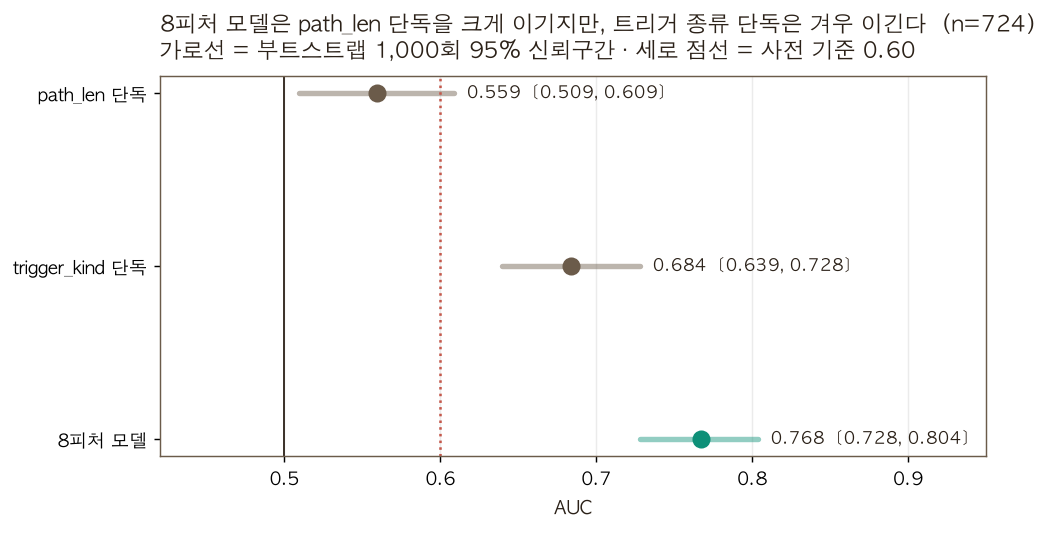

In [10]:
# 세 모델의 CI 를 같은 부트스트랩(1,000회·시드 0)으로 낸다
ci = {name: _bootstrap_ci(y, o, n_boot=1000, seed=SEED)
      for name, o in [("path_len 단독", oof_pathlen),
                      ("trigger_kind 단독", oof_trigkind),
                      ("8피처 모델", oof_full)]}
labels = list(ci)
vals = [auc_pathlen, auc_trigkind, auc_full]

fig, ax = R.new("8피처 모델은 path_len 단독을 크게 이기지만, 트리거 종류 단독은 겨우 이긴다", n=len(y),
                sub="가로선 = 부트스트랩 1,000회 95% 신뢰구간 · 세로 점선 = 사전 기준 0.60",
                figsize=(8.2, 3.8))
for i, (lab, v) in enumerate(zip(labels, vals)):
    lo, hi = ci[lab]
    c = R.PALETTE[2] if lab == "8피처 모델" else R.MUTED
    ax.plot([lo, hi], [i, i], color=c, lw=3, solid_capstyle="round", alpha=0.45)
    ax.plot([v], [i], "o", color=c, ms=9)
    ax.text(hi + 0.008, i, f"{v:.3f}  [{lo:.3f}, {hi:.3f}]", va="center", fontsize=9.5, color=R.INK)
ax.axvline(0.5, color=R.INK, lw=1.0)
ax.axvline(0.60, color=R.PALETTE[0], lw=1.4, ls=":")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels); ax.invert_yaxis()
ax.set_xlim(0.42, 0.95); ax.set_xlabel("AUC")
ax.grid(axis="y", visible=False)
R.show(R.save(fig, ax, "g_ch_baseline", zero_base=False))

### 읽은 것

- **다수 클래스 정확도 69.9%.** "아무도 안 떠난다" 고만 답해도 열 번 중 일곱 번 맞는다.
  정확도를 성과로 쓰면 안 되는 이유다 — 그래서 주 지표를 AUC 로 뒀다.
- **`path_len` 단독 0.559 → 8피처 0.768.** 사전등록 §5 의 기각 조건
  ("단일 피처를 못 이기면 기각")은 **넉넉히 통과** 했다.
- **`trigger_kind` 단독 0.684 → 8피처 0.768.** 좌표 피처 7개를 다 넣고 얻은 건 **+0.084** 다.
  두 신뢰구간은 0.728 에서 겨우 맞닿는다([0.639, 0.728] vs [0.728, 0.804]).
  같은 표본으로 잰 값이라 구간이 안 겹친다고 "확실히 다르다" 고 말할 수는 없지만,
  **모델이 배운 것의 상당 부분은 트리거 종류** 라는 건 분명하다.

이 관찰이 5절 판정의 성격을 바꾼다. 판정은 통과지만, 통과의 내용이 기대와 다르다.

## 4. 모델 — GroupKFold 5겹 + 부트스트랩 1,000회

**GroupKFold(client_id)** 는 같은 사람의 세션이 학습과 검증에 동시에 들어가지 않게 나누는 방식이다.
그냥 섞어 나누면 "이 사람 습관" 을 외워서 성능이 뻥튀기된다.

**부트스트랩** 은 가진 표본에서 복원추출로 724건을 1,000번 다시 뽑아 매번 AUC 를 재는 것이다.
그 1,000개가 퍼진 폭이 "표본이 조금만 달랐어도 이 정도로 흔들렸겠다" 는 범위 = 신뢰구간이다.

In [11]:
def boot_aucs(y_, p_, n_boot=1000, seed=SEED):
    # 부트스트랩 AUC 분포. train_churn._bootstrap_ci 와 같은 절차를 쓰되
    # 백분위만이 아니라 분포 전체를 돌려준다(히스토그램을 그리려고).
    # 아래에서 _bootstrap_ci 의 값과 일치하는지 대조한다 — 다르면 둘 중 하나가 틀린 것이다.
    from sklearn.metrics import roc_auc_score
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y_))
    out = []
    for _ in range(n_boot):
        s = rng.choice(idx, size=len(idx), replace=True)
        if len(np.unique(y_[s])) < 2:      # 한 클래스만 뽑히면 AUC 가 정의되지 않는다
            continue
        out.append(roc_auc_score(y_[s], p_[s]))
    return np.array(out)

b = boot_aucs(y, oof_full)
ci_low, ci_high = np.percentile(b, [2.5, 97.5])
ref_low, ref_high = _bootstrap_ci(y, oof_full, n_boot=1000, seed=SEED)
assert abs(ci_low - ref_low) < 1e-9 and abs(ci_high - ref_high) < 1e-9, "학습 코드와 값이 다르다"
print(f"AUC {auc_full:.4f} · 95% CI [{ci_low:.4f}, {ci_high:.4f}] · 부트스트랩 유효 {len(b):,}회")
print(f"CI 하한이 0.60 을 넘는가 → {ci_low > 0.60}")
print(f"부트스트랩 표본 중 0.60 아래로 내려간 비율 {np.mean(b <= 0.60):.1%}")

AUC 0.7676 · 95% CI [0.7280, 0.8040] · 부트스트랩 유효 1,000회
CI 하한이 0.60 을 넘는가 → True
부트스트랩 표본 중 0.60 아래로 내려간 비율 0.0%


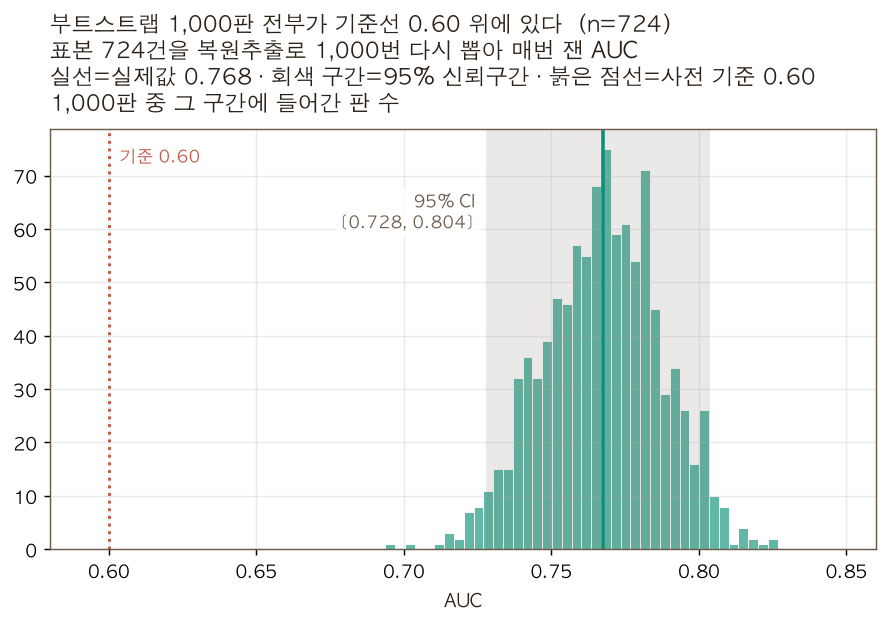

In [12]:
fig, ax = R.new("부트스트랩 1,000판 전부가 기준선 0.60 위에 있다", n=len(y),
                sub=f"표본 {len(y):,}건을 복원추출로 1,000번 다시 뽑아 매번 잰 AUC\n"
                    f"실선=실제값 {auc_full:.3f} · 회색 구간=95% 신뢰구간 · 붉은 점선=사전 기준 0.60",
                ylab="1,000판 중 그 구간에 들어간 판 수", figsize=(8.2, 4.2))
ax.hist(b, bins=40, color=R.tint(R.PALETTE[2], 0.35), edgecolor="white", lw=0.5)
ax.axvspan(ci_low, ci_high, color=R.MUTED, alpha=0.13, lw=0)
ax.axvline(auc_full, color=R.PALETTE[2], lw=2.0)
ax.axvline(0.60, color=R.PALETTE[0], lw=1.6, ls=":")
ax.annotate("기준 0.60", (0.60, ax.get_ylim()[1] * 0.92), xytext=(6, 0),
            textcoords="offset points", color=R.PALETTE[0], fontsize=9.5)
# 막대 위에 겹치지 않게 흰 배경을 깔고 구간 왼쪽 바깥에 붙인다(실측 확인)
ax.annotate(f"95% CI\n[{ci_low:.3f}, {ci_high:.3f}]", (ci_low, ax.get_ylim()[1] * 0.80),
            xytext=(-6, 0), textcoords="offset points", ha="right", va="center",
            color=R.MUTED, fontsize=9.5,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=2))
ax.set_xlabel("AUC")
ax.set_xlim(0.58, 0.86)
R.show(R.save(fig, ax, "g_ch_boot"))

### 읽은 것

1,000판 중 **0.60 아래로 내려간 판이 하나도 없다.** 신뢰구간은 [0.728, 0.804] 이고
하한이 기준선보다 0.13 위에 있다. 표본이 조금 달랐어도 판정이 뒤집히지는 않는다.

**다만 이건 두 트리거를 섞어 잰 값이다.** 다음 절이 그걸 쪼갠다.

### 트리거 안에서만 재면

실제 서빙에서 모델은 **트리거 종류를 이미 아는 상태** 로 점수를 매기고,
**그 트리거의 기저율을 임계값으로** 판정한다(설계서 §4). 그러니 실전 성능은
"섞어서 순위 매기기" 가 아니라 **"같은 트리거 안에서 누가 더 위험한가"** 다.

그래서 `trigger_kind` 를 뺀 좌표 피처 7개로, 각 트리거 안에서만 다시 잰다.

In [13]:
IDX7 = [i for i, f in enumerate(FEATURE_ORDER) if f != "trigger_kind"]   # 트리거 종류 제외

within = {}
for k in order:
    m = (df.trigger_kind == k).to_numpy()
    a, o = _cv_oof(X[np.ix_(m, IDX7)], y[m], groups[m])
    lo, hi = _bootstrap_ci(y[m], o, n_boot=1000, seed=SEED)
    within[k] = dict(auc=a, lo=lo, hi=hi, n=int(m.sum()), base=float(y[m].mean()))
    print(f"{KO_TRIG[k]:8s} n={m.sum():>4,}  AUC {a:.4f}  CI [{lo:.4f}, {hi:.4f}]  기저율 {y[m].mean():.1%}")

접속 15초   n= 284  AUC 0.6441  CI [0.5776, 0.7070]  기저율 55.3%


퀘스트 접촉   n= 440  AUC 0.5970  CI [0.5159, 0.6739]  기저율 13.9%


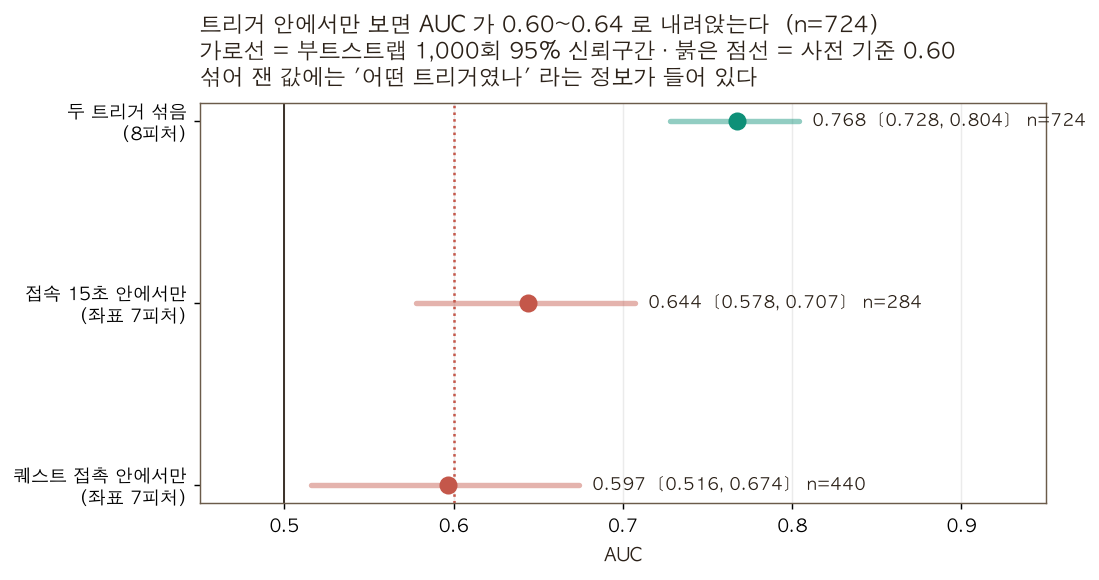

In [14]:
rows = [("두 트리거 섞음\n(8피처)", auc_full, ci_low, ci_high, len(y))] + [
    (f"{KO_TRIG[k]} 안에서만\n(좌표 7피처)", within[k]["auc"], within[k]["lo"], within[k]["hi"], within[k]["n"])
    for k in order]

fig, ax = R.new("트리거 안에서만 보면 AUC 가 0.60~0.64 로 내려앉는다", n=len(y),
                sub="가로선 = 부트스트랩 1,000회 95% 신뢰구간 · 붉은 점선 = 사전 기준 0.60\n"
                    "섞어 잰 값에는 '어떤 트리거였나' 라는 정보가 들어 있다",
                figsize=(8.4, 4.0))
for i, (lab, v, lo, hi, nn) in enumerate(rows):
    c = R.PALETTE[2] if i == 0 else R.PALETTE[0]
    ax.plot([lo, hi], [i, i], color=c, lw=3, solid_capstyle="round", alpha=0.45)
    ax.plot([v], [i], "o", color=c, ms=9)
    ax.text(hi + 0.008, i, f"{v:.3f}  [{lo:.3f}, {hi:.3f}]   n={nn:,}",
            va="center", fontsize=9.5, color=R.INK)
ax.axvline(0.5, color=R.INK, lw=1.0)
ax.axvline(0.60, color=R.PALETTE[0], lw=1.4, ls=":")
ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows]); ax.invert_yaxis()
ax.set_xlim(0.45, 0.95); ax.set_xlabel("AUC")
ax.grid(axis="y", visible=False)
R.show(R.save(fig, ax, "g_ch_within", zero_base=False))

### 읽은 것 — 이 노트북에서 제일 중요한 그림이다

| 어디서 재나 | n | AUC | 95% CI |
|---|---|---|---|
| 두 트리거 섞음(8피처) | 724 | **0.768** | [0.728, 0.804] |
| 접속 15초 안에서만 | 284 | 0.644 | [0.578, 0.707] |
| 퀘스트 접촉 안에서만 | 440 | 0.597 | [0.516, 0.674] |

**섞어 잰 0.768 중 상당 부분은 "지금 어떤 트리거냐" 를 아는 데서 온다.**
같은 트리거 안에서만 순위를 매기게 하면 15초는 0.644, 퀘스트는 0.597 이고
**두 신뢰구간 모두 하한이 0.60 아래** 다(0.578 · 0.516).

사전 기준을 트리거별로 적용했다면 둘 다 **"보류"** 였을 것이다.
사전등록은 전체 표본 하나에 기준을 걸었으므로 판정은 통과가 맞지만,
**이 표를 빼고 "AUC 0.77 나왔다" 만 말하면 오해를 만든다.**

## 5. 판정 — 사전 기준 대비

기준은 착수 전에 고정했다. 사후에 내리지도 올리지도 않는다.

In [15]:
BANDS = [(0.00, 0.50, "❌ 기각",   "모델 접고 첫 세션 퍼널 분석으로 전환"),
         (0.50, 0.60, "🔸 보류",   "데이터 더 모아 재시도"),
         (0.60, 1.00, "✅ 신호 있음", "상위 피처를 UX 가설로 전환")]

verdict = next((v, act) for lo_, hi_, v, act in BANDS if lo_ < ci_low <= hi_)
print(f"AUC {auc_full:.4f} · 95% CI 하한 {ci_low:.4f}")
print(f"판정: {verdict[0]}  →  {verdict[1]}")
print()
print("베이스라인 대조(사전등록 §5):")
print(f"  ① 다수 클래스 정확도      {base_majority:.3f}  ← 정확도를 성과로 쓰지 않는 근거")
print(f"  ② path_len 단독 AUC       {auc_pathlen:.3f}  → 8피처가 {auc_full - auc_pathlen:+.3f} 로 이김 (기각 조건 아님)")
print(f"  ③ trigger_kind 단독 AUC   {auc_trigkind:.3f}  → 8피처가 {auc_full - auc_trigkind:+.3f} 로 이김 (사전등록 밖 추가 대조)")

AUC 0.7676 · 95% CI 하한 0.7280
판정: ✅ 신호 있음  →  상위 피처를 UX 가설로 전환

베이스라인 대조(사전등록 §5):
  ① 다수 클래스 정확도      0.699  ← 정확도를 성과로 쓰지 않는 근거
  ② path_len 단독 AUC       0.559  → 8피처가 +0.208 로 이김 (기각 조건 아님)
  ③ trigger_kind 단독 AUC   0.684  → 8피처가 +0.083 로 이김 (사전등록 밖 추가 대조)


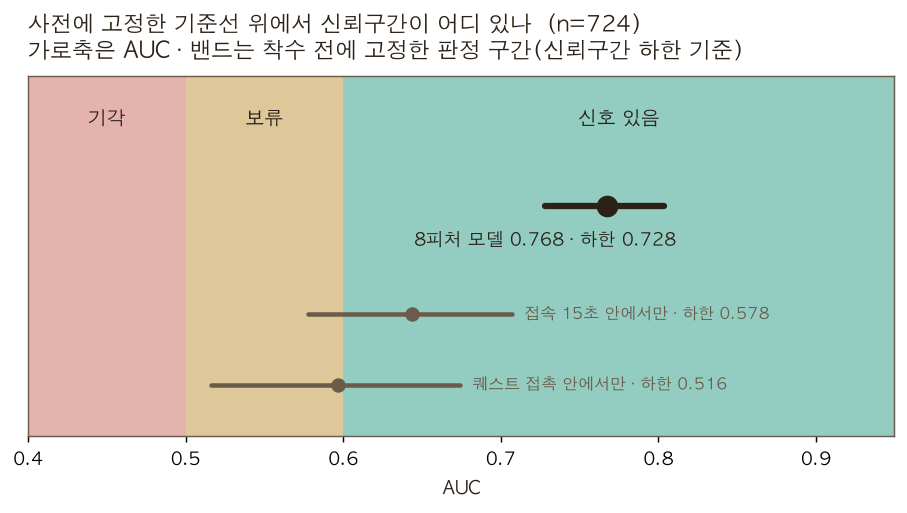

In [16]:
fig, ax = R.new("사전에 고정한 기준선 위에서 신뢰구간이 어디 있나", n=len(y),
                sub="가로축은 AUC · 밴드는 착수 전에 고정한 판정 구간(신뢰구간 하한 기준)",
                figsize=(8.6, 3.6))
band_colors = [R.tint(R.PALETTE[0], 0.55), R.tint(R.PALETTE[3], 0.55), R.tint(R.PALETTE[2], 0.55)]
for (lo_, hi_, name, _), c in zip(BANDS, band_colors):
    ax.axvspan(max(lo_, 0.40), min(hi_, 0.95), color=c, lw=0)
    # 이모지는 AppleGothic 에 글리프가 없어 차트에서 ▯ 로 나온다 — 밴드 이름만 쓴다
    ax.text((max(lo_, 0.40) + min(hi_, 0.95)) / 2, 1.30, name.split(" ", 1)[-1],
            ha="center", fontsize=10.5, color=R.INK)

ax.plot([ci_low, ci_high], [1.0, 1.0], color=R.INK, lw=3.5, solid_capstyle="round")
ax.plot([auc_full], [1.0], "o", color=R.INK, ms=11)
ax.annotate(f"8피처 모델 {auc_full:.3f} · 하한 {ci_low:.3f}", (ci_low, 1.0), xytext=(0, -22),
            textcoords="offset points", ha="center", fontsize=10, color=R.INK)
for i, k in enumerate(order):
    w = within[k]
    yy = 0.60 - i * 0.26
    ax.plot([w["lo"], w["hi"]], [yy] * 2, color=R.MUTED, lw=2.5, solid_capstyle="round")
    ax.plot([w["auc"]], [yy], "o", color=R.MUTED, ms=7)
    ax.text(w["hi"] + 0.008, yy, f"{KO_TRIG[k]} 안에서만 · 하한 {w['lo']:.3f}",
            va="center", fontsize=9, color=R.MUTED)

ax.set_xlim(0.40, 0.95); ax.set_ylim(0.15, 1.48)
ax.set_yticks([]); ax.set_xlabel("AUC")
ax.grid(visible=False)
R.show(R.save(fig, ax, "g_ch_verdict", zero_base=False))

### 판정 — ✅ 신호 있음 (조건부로 읽을 것)

**AUC 0.768, 95% CI [0.728, 0.804]. 하한 0.728 > 0.60 → 사전 기준 "신호 있음".**

사전등록 §5 의 기각 조건(`path_len` 단독을 못 이김)에도 걸리지 않는다 — 0.559 → 0.768.

**그런데 같은 그림 아래쪽의 회색 두 줄을 같이 봐야 한다.** 트리거 안에서만 재면
하한이 0.578 · 0.516 으로 **"보류" 밴드에 들어간다.** 이 노트북의 판정은
"전체 표본 하나에 기준을 건다" 는 사전등록 문구를 그대로 따른 결과지, 사후에 유리한 축을 고른 게 아니다.

**설계서 §12 대로 파이프라인은 유지한다** — 기준 미달이었어도 유지였고,
지금은 통과했으니 더더욱 유지한다. 계수는 주 1회 DAG 가 갈아끼운다.

### 서빙에 나가는 계수와 같은 값인가

위 숫자는 노트북이 계산한 것이다. 실제로 API 에 배포되는 `coef.json` 을
**같은 표본으로 한 번 더 만들어** 지표가 일치하는지 대조한다.
(W&B 업로드는 끄고, 임시 경로에 쓴다 — 이 노트북이 서빙 계수를 덮어쓰면 안 된다.)

In [17]:
import json, tempfile

with tempfile.TemporaryDirectory() as tmp:
    model = fit_and_export(df, Path(tmp) / "coef.json", log_wandb=False)

m = model["metrics"]
assert abs(m["auc"] - auc_full) < 1e-9, "학습 코드와 노트북의 AUC 가 다르다"
assert abs(m["auc_ci_low"] - ci_low) < 1e-9, "CI 하한이 다르다"
print("model_version:", model["model_version"])
print("threshold(트리거별 기저율):", json.dumps(model["threshold"], ensure_ascii=False))
print(json.dumps(m, ensure_ascii=False, indent=2))

coef = (pd.Series(model["coef"], index=FEATURE_ORDER)
          .rename("표준화 계수").sort_values(key=abs, ascending=False))
print("\n계수(표준화 후 · 부호가 +면 값이 클수록 이탈):")
print(coef.round(3).to_string())

model_version: 2026-09-06T05:27:43Z
threshold(트리거별 기저율): {"time15": 0.5528169014084507, "quest": 0.13863636363636364}
{
  "auc": 0.7676052507524387,
  "auc_ci_low": 0.727950539141704,
  "auc_ci_high": 0.8039624561567228,
  "baseline_majority": 0.6988950276243093,
  "baseline_pathlen_auc": 0.5593927910940275,
  "baseline_triggerkind_auc": 0.6841344236138811,
  "n": 724,
  "churn_rate": 0.3011049723756906
}

계수(표준화 후 · 부호가 +면 값이 클수록 이탈):
trigger_kind       -0.901
path_len            0.689
mouse_travel       -0.516
is_first_session    0.298
net_disp           -0.251
wander_ratio       -0.128
yaw_total          -0.103
idle_ratio          0.019


계수는 표준화된 값이라 서로 비교할 수 있다. 부호가 `+` 면 "값이 클수록 이탈" 이다.
`trigger_kind` 는 0=15초 / 1=퀘스트 이므로 **음수 계수 = 퀘스트 쪽이 덜 이탈** 이라는 뜻이고,
1절에서 본 기저율 차이(55.3% vs 13.9%)와 같은 이야기다.

**계수 크기를 "중요도" 로 읽지 말 것.** 피처끼리 상관이 있으면 계수는 서로 나눠 가진다.

## 그래서 크기가 얼마나 되나

AUC 는 "순위를 맞히는 확률" 이라 감이 안 온다. 실제로 배포된 규칙 —
**점수가 그 트리거의 기저율을 넘으면 배너를 띄운다** — 를 그대로 적용하면
몇 명한테 뜨고, 그중 진짜 떠나려던 사람이 몇 명인지 본다.

In [18]:
th = _thresholds(df, y)                        # 서빙에 나가는 것과 같은 임계값
kind = df.trigger_kind.to_numpy()
thr = np.array([th[k] for k in kind])
fire = oof_full >= thr                         # 배너를 띄웠을 트리거

rows = []
for k in order + [None]:
    m_ = np.ones(len(y), bool) if k is None else (kind == k)
    f = fire & m_
    rows.append({
        "구간": "전체" if k is None else KO_TRIG[k],
        "트리거 수": int(m_.sum()),
        "배너 뜸": int(f.sum()),
        "배너 비율": f.sum() / m_.sum(),
        "배너 뜬 쪽 실제 이탈률": float(y[f].mean()),
        "그냥 평균(기저율)": float(y[m_].mean()),
        "이탈자 중 잡은 비율": float(y[f].sum() / y[m_].sum()),
    })
op = pd.DataFrame(rows).set_index("구간")
op["기저율 대비"] = op["배너 뜬 쪽 실제 이탈률"] / op["그냥 평균(기저율)"]
print("임계값:", {k: round(v, 4) for k, v in th.items()})
print()
pct = {c: "{:.1%}".format for c in ["배너 비율", "배너 뜬 쪽 실제 이탈률",
                                    "그냥 평균(기저율)", "이탈자 중 잡은 비율"]}
print(op.to_string(formatters={**pct, "기저율 대비": "{:.2f}배".format}))

임계값: {'time15': 0.5528, 'quest': 0.1386}

        트리거 수  배너 뜸 배너 비율 배너 뜬 쪽 실제 이탈률 그냥 평균(기저율) 이탈자 중 잡은 비율 기저율 대비
구간                                                                   
접속 15초    284   144 50.7%         64.6%      55.3%       59.2%  1.17배
퀘스트 접촉    440   234 53.2%         15.4%      13.9%       59.0%  1.11배
전체        724   378 52.2%         34.1%      30.1%       59.2%  1.13배


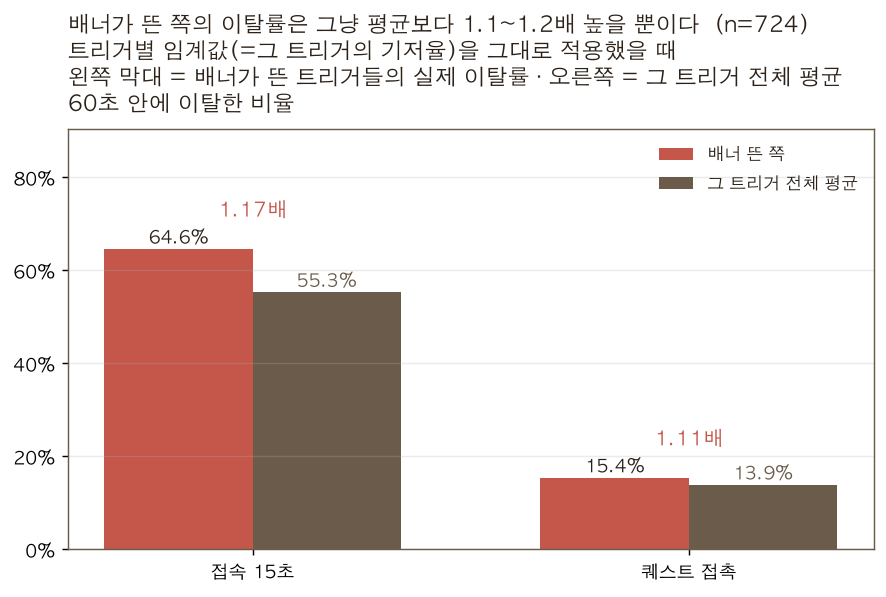

In [19]:
fig, ax = R.new("배너가 뜬 쪽의 이탈률은 그냥 평균보다 1.1~1.2배 높을 뿐이다", n=len(y),
                sub="트리거별 임계값(=그 트리거의 기저율)을 그대로 적용했을 때\n"
                    "왼쪽 막대 = 배너가 뜬 트리거들의 실제 이탈률 · 오른쪽 = 그 트리거 전체 평균",
                ylab="60초 안에 이탈한 비율", figsize=(8.0, 4.2))
w = 0.34
xs = np.arange(len(order))
hit = [op.loc[KO_TRIG[k], "배너 뜬 쪽 실제 이탈률"] for k in order]
base = [op.loc[KO_TRIG[k], "그냥 평균(기저율)"] for k in order]
ax.bar(xs - w / 2, hit, w, color=R.PALETTE[0], label="배너 뜬 쪽")
ax.bar(xs + w / 2, base, w, color=R.MUTED, label="그 트리거 전체 평균")
for x, h, bb in zip(xs, hit, base):
    ax.text(x - w / 2, h + 0.012, f"{h:.1%}", ha="center", fontsize=10, color=R.INK)
    ax.text(x + w / 2, bb + 0.012, f"{bb:.1%}", ha="center", fontsize=10, color=R.MUTED)
    ax.text(x, max(h, bb) + 0.07, f"{h / bb:.2f}배", ha="center", fontsize=11, color=R.PALETTE[0])
ax.set_xticks(xs); ax.set_xticklabels([KO_TRIG[k] for k in order])
ax.set_ylim(0, max(hit) * 1.4)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(frameon=False, fontsize=9.5, loc="upper right")
ax.grid(axis="x", visible=False)
R.show(R.save(fig, ax, "g_ch_operating"))

### 크기 — 세 가지 방식으로

**① 원래 단위로.** 트리거 724건 중 **378건(52.2%)** 에 배너가 뜬다.
배너가 뜬 쪽의 실제 이탈률은 34.1% 로 전체 평균 30.1% 보다 **4.0%p** 높다.

**② 양 끝을 나란히.** 트리거 안에서 보면
- 접속 15초: 배너 뜬 쪽 **64.6%** vs 그 트리거 평균 **55.3%** → **1.17배**
- 퀘스트 접촉: 배너 뜬 쪽 **15.4%** vs 평균 **13.9%** → **1.11배**

**③ 설명력을 정직하게.** 임계값을 기저율에 두면 트리거의 **절반쯤**에 배너가 뜨고,
그중 잡히는 실제 이탈자는 전체 이탈자의 **59.2%** 다. 동전을 던져 절반을 골라도
이탈자의 50% 는 잡힌다. **모델이 벌어들인 건 그 위의 9%p 다.**

**정리하면 — 순위를 매기는 능력(AUC 0.768)에 비해, 실제 운영 임계값에서 얻는 이득은 작다.**
배너 대상을 절반으로 좁혀 이탈률 1.1~1.2배를 얻는 정도다. 개입 효과를 볼 때
"모델이 잘 골라줬으니 효과가 클 것" 이라고 기대하면 안 된다.

## 6. 병기 — 사전등록의 `span < 180` 라벨로도 한 번

사전등록 `CHURN_ANALYSIS_PLAN.md` §3 의 원래 라벨은 **"세션 전체 길이가 180초 미만이면 이탈"** 이고,
피처는 **세션 앞 10행** 에서 뽑는다. 지금 설계(트리거 직전 10행 → 트리거 후 60초)와 **축이 다르다.**

같은 걸 재는 게 아니므로 **참고용으로만 병기** 한다. 둘을 나란히 놓고 "어느 쪽이 낫다" 고
말할 수 없다 — 애초에 다른 질문에 답하는 숫자다.

In [20]:
# 옛 표본은 트리거 개념이 없어 trigger_kind 컬럼이 아예 없다.
# _prepare 가 8개를 요구하므로 상수로 채운다 → 분산이 0 이라 모델에 아무것도 기여하지 않는다.
df_old = bq.read_sql_file(str(ML / "sql" / "churn_sample.sql"), cap=5).assign(trigger_kind="time15")
X_o, y_o, g_o, _ = _prepare(df_old)
auc_old, oof_old = _cv_oof(X_o, y_o, g_o)
lo_o, hi_o = _bootstrap_ci(y_o, oof_old, n_boot=1000, seed=SEED)
auc_old_pl, _ = _cv_oof(X_o[:, [FEATURE_ORDER.index("path_len")]], y_o, g_o)

print("[참고] span<180 라벨 · 세션 앞 10행 피처")
print(f"  표본 {len(y_o):,}세션 · 클라이언트 {len(set(g_o)):,}명 · 이탈률 {y_o.mean():.1%}")
print(f"  AUC {auc_old:.4f}  CI [{lo_o:.4f}, {hi_o:.4f}]   (path_len 단독 {auc_old_pl:.4f})")
print(f"  CI 하한이 0.60 을 넘는가 → {lo_o > 0.60}")

[참고] span<180 라벨 · 세션 앞 10행 피처
  표본 335세션 · 클라이언트 205명 · 이탈률 70.4%
  AUC 0.7087  CI [0.6542, 0.7638]   (path_len 단독 0.6525)
  CI 하한이 0.60 을 넘는가 → True


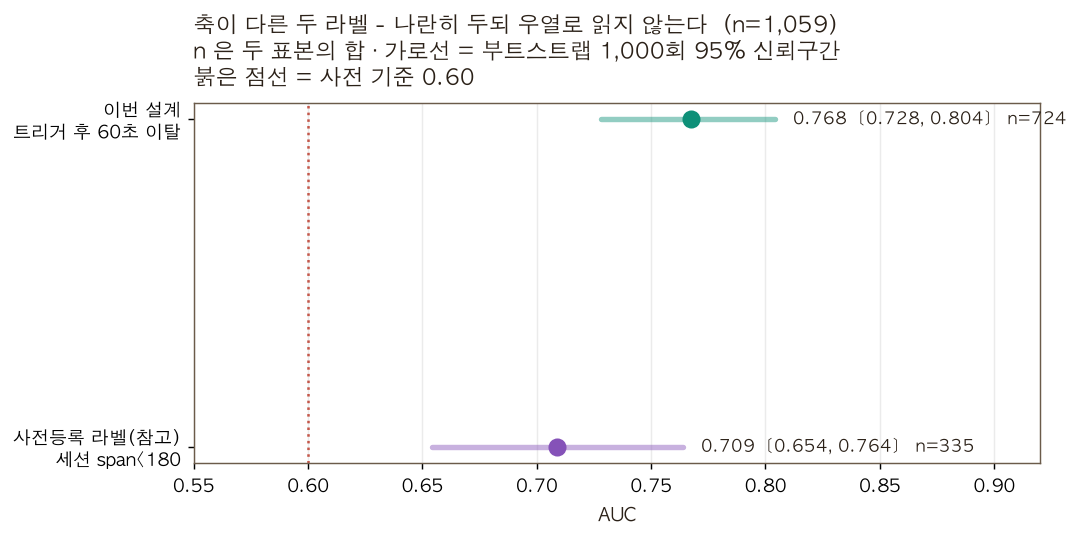

In [21]:
rows2 = [("이번 설계\n트리거 후 60초 이탈", auc_full, ci_low, ci_high, len(y), R.PALETTE[2]),
         ("사전등록 라벨(참고)\n세션 span<180", auc_old, lo_o, hi_o, len(y_o), R.PALETTE[4])]

fig, ax = R.new("축이 다른 두 라벨 - 나란히 두되 우열로 읽지 않는다", n=len(y) + len(y_o),
                sub="n 은 두 표본의 합 · 가로선 = 부트스트랩 1,000회 95% 신뢰구간\n"
                    "붉은 점선 = 사전 기준 0.60",
                figsize=(8.4, 3.6))
for i, (lab, v, lo_, hi_, nn, c) in enumerate(rows2):
    ax.plot([lo_, hi_], [i, i], color=c, lw=3, solid_capstyle="round", alpha=0.45)
    ax.plot([v], [i], "o", color=c, ms=9)
    ax.text(hi_ + 0.008, i, f"{v:.3f}  [{lo_:.3f}, {hi_:.3f}]   n={nn:,}",
            va="center", fontsize=9.5, color=R.INK)
ax.axvline(0.60, color=R.PALETTE[0], lw=1.4, ls=":")
ax.set_yticks(range(len(rows2))); ax.set_yticklabels([r[0] for r in rows2]); ax.invert_yaxis()
ax.set_xlim(0.55, 0.92); ax.set_xlabel("AUC")
ax.grid(axis="y", visible=False)
R.show(R.save(fig, ax, "g_ch_oldlabel", zero_base=False))

### 읽은 것

사전등록 라벨로는 **AUC 0.709, CI [0.654, 0.764]** (335세션, 이탈률 70.4%).
이쪽도 하한이 0.60 을 넘는다.

**두 숫자를 비교하면 안 된다.** 다른 표본(724 트리거 vs 335 세션),
다른 라벨(트리거 후 60초 vs 세션 총 180초), 다른 피처 구간(트리거 직전 10행 vs 세션 앞 10행)이다.
같은 방향을 가리킨다는 것만 확인한 것이고, **판정의 근거는 5절 하나** 다.

한 가지는 눈에 띈다 — 옛 축에서는 `path_len` 단독이 **0.653** 으로 꽤 세다.
"세션 앞 10행에서 얼마나 움직였나" 는 **세션이 짧을지** 를 어느 정도 예고하지만,
"트리거 직후 1분 안에 나갈지" 는 거의 예고하지 못한다(0.559). 라벨이 다르면 피처의 값도 달라진다.

## 이 숫자로 말할 수 없는 것

- **"AUC 0.77" 을 실전 성능으로 읽으면 안 된다.** 그 값에는 "지금 어떤 트리거냐" 가 섞여 있다.
  서빙은 트리거를 이미 알고 그 안에서 판정하므로 실전에 가까운 값은 **0.60~0.64** 다(4절).
- **효과 크기가 작다.** 운영 임계값에서 배너 대상의 이탈률은 기저율의 **1.11~1.17배**,
  절대차 1.5~9.3%p 다. "위험한 사람을 골라냈다" 고 말할 만한 크기가 아니다.
- **개입이 효과가 있는지는 이 노트북에 없다.** 여기 있는 건 "떠날 사람을 알아보는가" 뿐이다.
  배너를 띄우면 덜 떠나는지는 `arm=treat/control` 로 쌓이는 데이터가 따로 답해야 한다.
- **인과가 아니다.** 마우스를 안 움직여서 떠나는 게 아니라 떠나기로 해서 마우스를 놓았을 수 있다.
  이 피처들은 **이탈의 예고** 라기보다 **이탈의 초기 증상** 일 가능성이 크다.
- **표본 편중이 남아 있다.** 156명 중 상위 3명이 21.7%. `GroupKFold` 는 학습·검증 분리만 하지
  "이 3명의 습관이 계수를 정한다" 는 문제는 못 막는다.
- **15초 안에 나간 사람은 표본에 없다.** 좌표 10행을 못 채운 세션은 통째로 빠진다
  (사전등록 §8-4 의 알려진 한계). **제일 빨리 떠나는 사람들을 못 보고 만든 모델** 이다.
- **퀘스트 트리거의 인과 방향을 모른다.** 퀘스트가 이탈을 만드는지, 퀘스트를 끝냈으니 나가는지
  이 데이터로 안 갈린다.
- **시간 피처가 없다.** `logger.js` 가 샘플별 타임스탬프를 안 실어 "행 수 10개" 로 근사했다.
  속도·가속도·구간 체류 같은 진짜 시계열 피처는 아직 열리지 않았다.
- **표본이 이틀에 43% 늘었다**(507 → 724). 아직 자라는 중이라 다음 주 숫자는 다를 수 있다.
  판정이 뒤집힐 정도는 아니지만(하한이 0.128 여유), 소수 셋째 자리는 의미 없다.
- **로컬 테스트 세션 2건이 아직 안 걸러졌다**(2026-09-06). 724건 중 몇 건이라 위 값에
  영향은 거의 없지만, 다음 학습 전에 `churn_events` 에서 빼야 한다.

## 다음에 확인할 것

1. **트리거별로 따로 학습해 본다.** 지금은 하나의 계수 벡터가 두 트리거를 다 맡는다.
   기저율이 4배 차이나므로 나눠 학습하는 쪽이 나을 수 있다. 표본이 트리거당 284~440건이라
   지금 해도 무리는 아니다. 판정 기준도 트리거별로 다시 걸어야 한다.
2. **`mouse_travel` 이 예고인지 증상인지 가른다.** 트리거 **직전** 10행이 아니라
   트리거보다 30초·60초 앞선 창으로 같은 피처를 뽑아 AUC 가 얼마나 남는지 본다.
   앞당길수록 무너지면 그건 예고가 아니라 증상이다.
3. **`logger.js` 에 샘플별 `t` 를 싣는다**(사전등록 §7 의 최우선 항목, 아직 미이행).
   속도·정지 지속시간이 열리면 좌표 피처 6개가 지금처럼 무력하지 않을 수 있다.
4. **개발자 기기 `client_id` 를 확정해 뺀다.** 상위 3개가 본인 기기라면 21.7% 가 통째로 빠지고
   숫자가 달라진다. 이건 데이터가 아니라 사람이 확인할 것이다.
5. **`arm` 별 세션 연장 차이를 본다** — 처치군이 트리거 후 더 오래 남는지.
   베타 10명으로 유의성은 안 나온다(검정력 ~7%). **방향만** 보고 유의성은 주장하지 않는다.
6. **표본이 1,500건쯤 되면 판정을 다시 한다.** 그때는 트리거 안에서도 CI 폭이 좁아져
   0.60 위·아래가 갈릴 것이다. 기준은 그대로 쓴다.

---

**이 노트북이 만든 파일**: 없다. `fit_and_export` 는 임시 경로에 썼고 W&B 업로드도 껐다.
서빙 계수(`/opt/calm-api/model/coef.json`)는 Airflow DAG `churn_train` 만 갱신한다.

**차트 원본**: `ml/reports/figs/g_ch_*.png` (`.gitignore` 대상 — 노트북에 이미 임베드되어 있다)